Train size: (40000, 76) Test size: (10000, 76)


c:\Users\USER\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Model Accuracy: 0.7744

Classification Report:

              precision    recall  f1-score   support

           0       0.80      0.92      0.85      7110
           1       0.67      0.43      0.52      2890

    accuracy                           0.77     10000
   macro avg       0.73      0.67      0.69     10000
weighted avg       0.76      0.77      0.76     10000



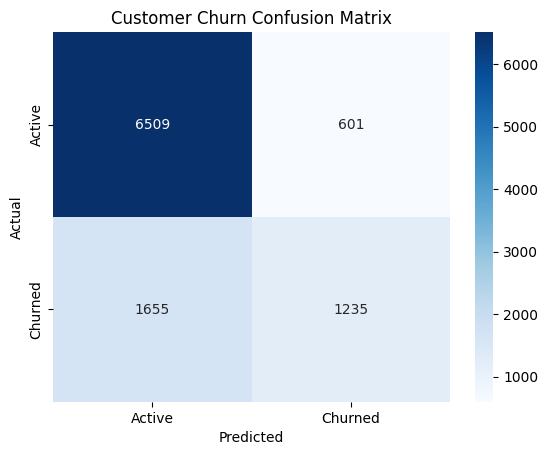

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Load feature engineered dataset
df = pd.read_csv("../data/processed/feature_engineered_data.csv")

# Define Features & Target
X = df.drop("Churned", axis=1)
y = df["Churned"]

X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape, "Test size:", X_test.shape)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)

print("\nModel Accuracy:", round(accuracy, 4))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Active", "Churned"],
            yticklabels=["Active", "Churned"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Customer Churn Confusion Matrix")
plt.show()